In [2]:
import numpy as np
from tensorflow.keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(60000, 784) / 255.0
x_test = x_test.reshape(10000, 784) / 255.0

# One-hot encode
def one_hot(labels, num_classes=10):
    result = np.zeros((len(labels), num_classes))
    for i, label in enumerate(labels):
        result[i][label] = 1
    return result

y_train_oh = one_hot(y_train)
y_test_oh = one_hot(y_test)

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def softmax(x):
    # FIXED: Handle batches properly
    # Subtract max per row for numerical stability
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# Neural Network
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = softmax(self.z2)
        return self.a2

    def backward(self, X, y_true, learning_rate=0.1):
        m = X.shape[0]
        dz2 = self.a2 - y_true
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m
        dz1 = np.dot(dz2, self.W2.T) * sigmoid_derivative(self.z1)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2

    def train(self, X, y, epochs=10, batch_size=64, learning_rate=0.1):
        num_samples = X.shape[0]

        for epoch in range(epochs):
            indices = np.random.permutation(num_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for i in range(0, num_samples, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]

                self.forward(X_batch)
                self.backward(X_batch, y_batch, learning_rate)

            # Calculate accuracy
            predictions = self.forward(X)
            accuracy = np.mean(np.argmax(predictions, axis=1) == np.argmax(y, axis=1))
            print(f"Epoch {epoch+1}/{epochs}, Accuracy: {accuracy:.4f}")

        print("✅ Training complete!")

# Train with FIXED learning rate
nn = NeuralNetwork(784, 64, 10)
print("🔥 Starting training with learning_rate=0.1...")
nn.train(x_train, y_train_oh, epochs=10, batch_size=64, learning_rate=0.6)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🔥 Starting training with learning_rate=0.1...
Epoch 1/10, Accuracy: 0.9276
Epoch 2/10, Accuracy: 0.9494
Epoch 3/10, Accuracy: 0.9587
Epoch 4/10, Accuracy: 0.9668
Epoch 5/10, Accuracy: 0.9702
Epoch 6/10, Accuracy: 0.9758
Epoch 7/10, Accuracy: 0.9789
Epoch 8/10, Accuracy: 0.9804
Epoch 9/10, Accuracy: 0.9823
Epoch 10/10, Accuracy: 0.9815
✅ Training complete!


In [4]:
test_preds = nn.forward(x_test)
test_predictions = np.argmax(test_preds, axis=1)
test_accuracy = np.mean(test_predictions == y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9703


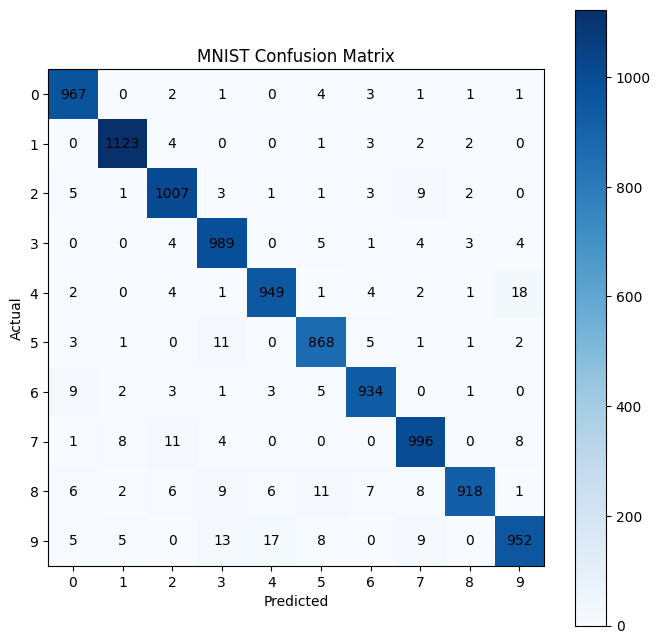

In [7]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, test_predictions)

plt.figure(figsize=(8, 8))
plt.imshow(cm, cmap="Blues")

# Add numbers inside each box
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MNIST Confusion Matrix")

plt.colorbar()
plt.xticks(range(10))
plt.yticks(range(10))

plt.show()

Total wrong predictions: 297


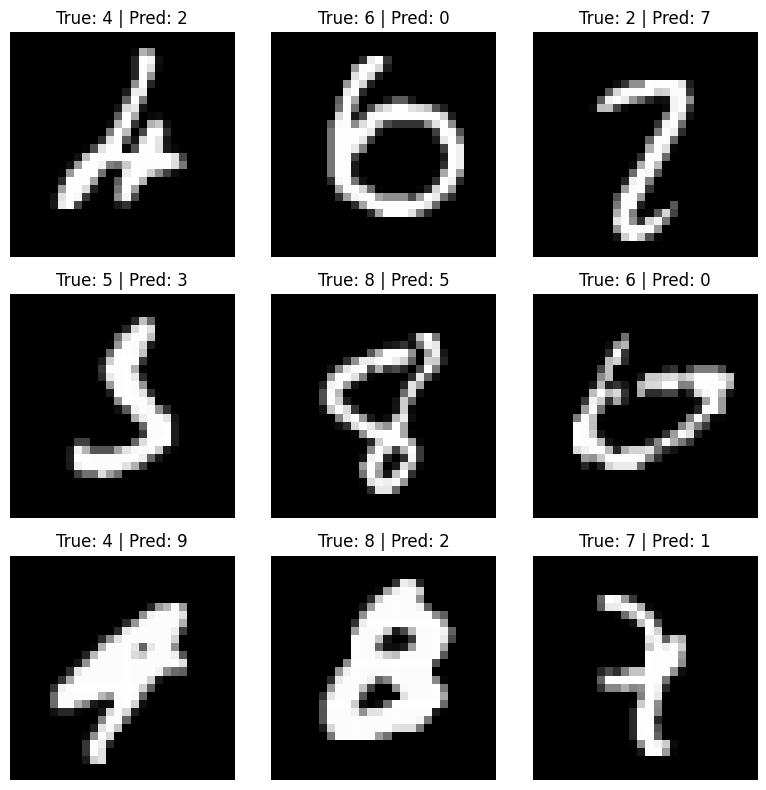

In [6]:
wrong_indices = np.where(test_predictions != y_test)[0]
print("Total wrong predictions:", len(wrong_indices))

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
axes = axes.flatten()

for i in range(9):
    idx = wrong_indices[i]

    axes[i].imshow(x_test[idx].reshape(28, 28), cmap="gray")

    axes[i].set_title(
        f"True: {y_test[idx]} | Pred: {test_predictions[idx]}"
    )

    axes[i].axis("off")

plt.tight_layout()
plt.show()